In [1]:
# Cell 1 — Load & inspect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco.csv")
print(df.shape)
print(df.dtypes)
df.head()

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


C:\Users\deven\AppData\Local\Temp\ipykernel_15592\2587030008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#4C72B0","#DD8452"])


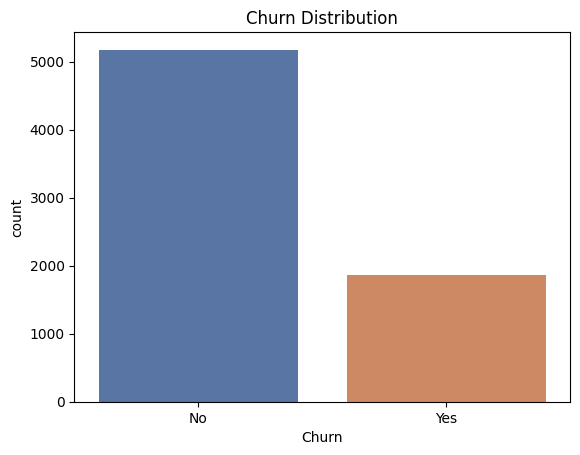

In [2]:
# Cell 2 — Churn rate overview
print("Churn distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

sns.countplot(data=df, x="Churn", palette=["#4C72B0","#DD8452"])
plt.title("Churn Distribution")
plt.show()

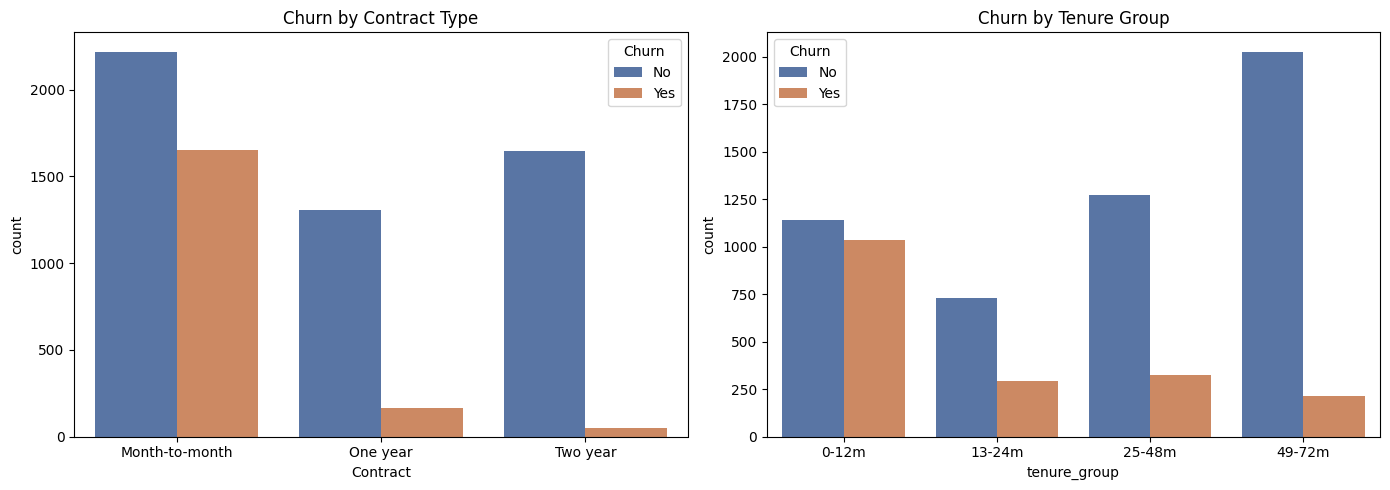

In [3]:
# Cell 3 — Churn by contract type & tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0],
              palette=["#4C72B0","#DD8452"])
axes[0].set_title("Churn by Contract Type")

df["tenure_group"] = pd.cut(df["tenure"],
    bins=[0,12,24,48,72], labels=["0-12m","13-24m","25-48m","49-72m"])
sns.countplot(data=df, x="tenure_group", hue="Churn", ax=axes[1],
              palette=["#4C72B0","#DD8452"])
axes[1].set_title("Churn by Tenure Group")

plt.tight_layout()
plt.show()

C:\Users\deven\AppData\Local\Temp\ipykernel_15592\1975225574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C72B0","#DD8452"])


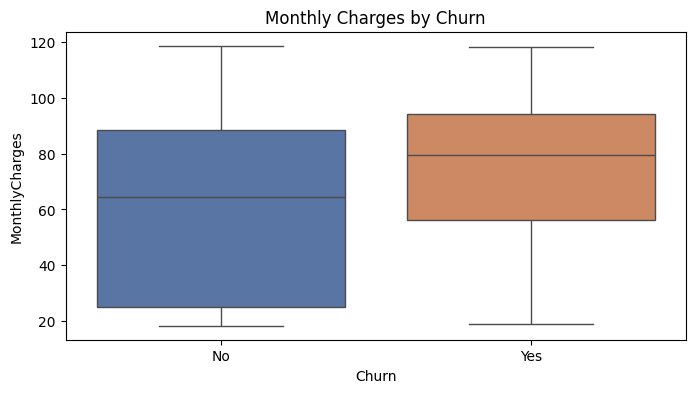

In [4]:
# Cell 4 — Monthly charges vs churn
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C72B0","#DD8452"])
plt.title("Monthly Charges by Churn")
plt.show()